# 5. Decision Tree and Random Forest
## Importing Dependencies

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,roc_auc_score

In [2]:
# import pandas as pd, matplotlib.pyplot as plt, seaborn as sns
# import sys
# from pathlib import Path

# # Add the project root (ml_laboratory) to Python's search path
# sys.path.append(str(Path().resolve().parent))
# from utils import (
#     eda_tabular
# )
# print("Imported")

# Loading and BAsic Data Analysis

In [4]:
def load_dataset(filepath,column_names=None,seperator=","):
    df=pd.read_csv(filepath,names=column_names,sep=seperator)
    df.columns = df.columns.str.strip()
    return df

def dataset_info(df):
    print("-" * 50)
    print("DATASET INFORMATION")
    print("-"*50)

    print("\n Shape: ",df.shape)
    print("\nColumns: ")
    print(df.columns.tolist())

    print("\nData Types: ")
    print(df.dtypes)

    print("\nMemory information")
    df.info()

    print("First 5 elements")
    print(df.head())
def missing_values(df):
    missing=df.isnull().sum()
    percent=(missing/len(df) )*100

    result=pd.DataFrame(
    {"missing":missing,
    "percent":percent
    })

    print(result)

    if (missing.sum() ==0):
        print("There is no missing value!")
    else:
        print("\033[31mMissing Values detected\033[0m")
    return result

def duplicate_info(df):
    duplicates = df.duplicated().sum()
    print("\nThe duplicate rows are : ",duplicates);

    if(duplicates ==0):
        print("No duplicates detected!")
    else:
        print("\033[31mDuplicates are detected\033[0m")

    return duplicates

def summary_statistics(df):
    print("\nSummary statsitics")
    print(df.describe())

   

In [5]:
def basic_eda(filepath,column_names=None,separator=",",):

    
    df = load_dataset(
        filepath,
        column_names=column_names,
        seperator=separator
    )

    print("\nLoading dataset completed\n")

    dataset_info(df)
    missing_values(df)
    duplicate_info(df)
    summary_statistics(df)

    return df
def class_distribution(df,target_column):
    print("\nClass Distribution")

    counts=df[target_column].value_counts()
    plot=counts.plot(kind="bar")
    plt.xlabel(target_column)
    plt.ylabel("Count")
    plt.title(f"Class Distribution of {target_column}")

    for container in plot.containers:
        plot.bar_label(container)
    plt.show()


In [28]:
def class_distribution(df,target_column):
    print("\nClass Distribution")

    counts=df[target_column].value_counts()
    counts.plot(kind="bar")
    plt.xlabel(target_column)
    plt.ylabel("Count")
    plt.title(f"Class Distribution of {target_column}")
    plt.show()

    return counts
def plot_histogram(df,bins=10):
    numeric_df=df.select_dtypes("number")
    if "id" in numeric_df.columns:
        numeric_df = numeric_df.drop(columns=["id"])
    # n_cols = len(numeric_df.columns)
    
    numeric_df.hist(bins=bins,figsize=(16,12) )
    plt.suptitle("Histogram of numerical features")
    plt.tight_layout()
    plt.show()

def plot_boxplot(df):
    numeric_df = df.select_dtypes("number")

    for col in numeric_df.columns:
        plt.boxplot(numeric_df[col])
        plt.title("BoxPlot of "+str(col))
        plt.show()
def plot_heatmap(df,max_annot_cols=10):
    numeric_df = df.select_dtypes("number")

    if "id" in numeric_df.columns:
        numeric_df = numeric_df.drop(columns=["id"])

    num_vars = len(numeric_df.columns)
    corr = numeric_df.corr()
    show_annot = num_vars <= max_annot_cols

    fig_width = max(8, num_vars * 0.45)
    fig_height = max(6, num_vars * 0.40)
    plt.figure(figsize=(fig_width, fig_height))
    
    sns.heatmap(corr,annot=show_annot,fmt=".2f",annot_kws={"size": 8},cmap="coolwarm",center=0,
                linewidths=0.5 if num_vars < 25 else 0)
    plt.title("Heatmap !")
    plt.tight_layout()
    plt.show()

def plot_scatterplot(df,target_column=None):

    if (target_column is not None):
        sns.pairplot(df,hue=target_column)
    else:
        sns.pairplot(df)
    plt.suptitle("Pairplot")
    plt.tight_layout()
    plt.show()

def plot_target_distribution(df,target_column):
    plt.figure(figsize=(8,5))
    sns.histplot(df[target_column],kde=True,bins=30)
    plt.xlabel(target_column)
    plt.ylabel("Frequency")
    plt.title(f"Distribution of {target_column}")
    plt.show()

def plot_feature_target(df,feature_columns,target_column):
    for col in feature_columns:
        plt.figure(figsize=(6,4))
        plt.scatter(df[col],df[target_column],alpha=0.5)
        plt.xlabel(col)
        plt.ylabel(target_column)
        plt.title(f"{col} vs {target_column}")
        plt.show()



In [29]:
def perform_eda(
    filepath,
    target_column=None,
    categorical_columns=None,
    pairplot_columns=None,
    column_names=None,
    separator=",",

    show_histogram=True,
    show_boxplot=True,
    show_heatmap=True,
    show_pairplot=True,
    show_target_dist=True,
    feature_target_cols=None
):

    df = load_dataset(
        filepath,
        column_names=column_names,
        seperator=separator
    )

    print("\nLoading dataset completed\n")

    dataset_info(df)
    missing_values(df)
    duplicate_info(df)
    summary_statistics(df)



    if show_histogram:
        plot_histogram(df)

    if show_boxplot:
        plot_boxplot(df)

    if show_heatmap:
        plot_heatmap(df)

    if show_target_dist and target_column is not None:
        plot_target_distribution(df,target_column)

    if feature_target_cols is not None and target_column is not None:
        plot_feature_target(df,feature_target_cols,target_column)

    if show_pairplot:

        if pairplot_columns is not None:

            if target_column is not None:
                plot_scatterplot(
                    df[pairplot_columns + [target_column]],
                    target_column
                )

            else:
                plot_scatterplot(
                    df[pairplot_columns]
                )

        else:
            print("\nPairplot skipped (No columns specified).")

    
    if categorical_columns is not None:
        for col in categorical_columns:
            class_distribution(df, col)

    return df

## EDA Analysis


Loading dataset completed

--------------------------------------------------
DATASET INFORMATION
--------------------------------------------------

 Shape:  (569, 32)

Columns: 
['id', 'diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean', 'concave_points_mean', 'symmetry_mean', 'fractal_dimension_mean', 'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se', 'compactness_se', 'concavity_se', 'concave_points_se', 'symmetry_se', 'fractal_dimension_se', 'radius_worst', 'texture_worst', 'perimeter_worst', 'area_worst', 'smoothness_worst', 'compactness_worst', 'concavity_worst', 'concave_points_worst', 'symmetry_worst', 'fractal_dimension_worst']

Data Types: 
id                           int64
diagnosis                      str
radius_mean                float64
texture_mean               float64
perimeter_mean             float64
area_mean                  float64
smoothness_mean            flo

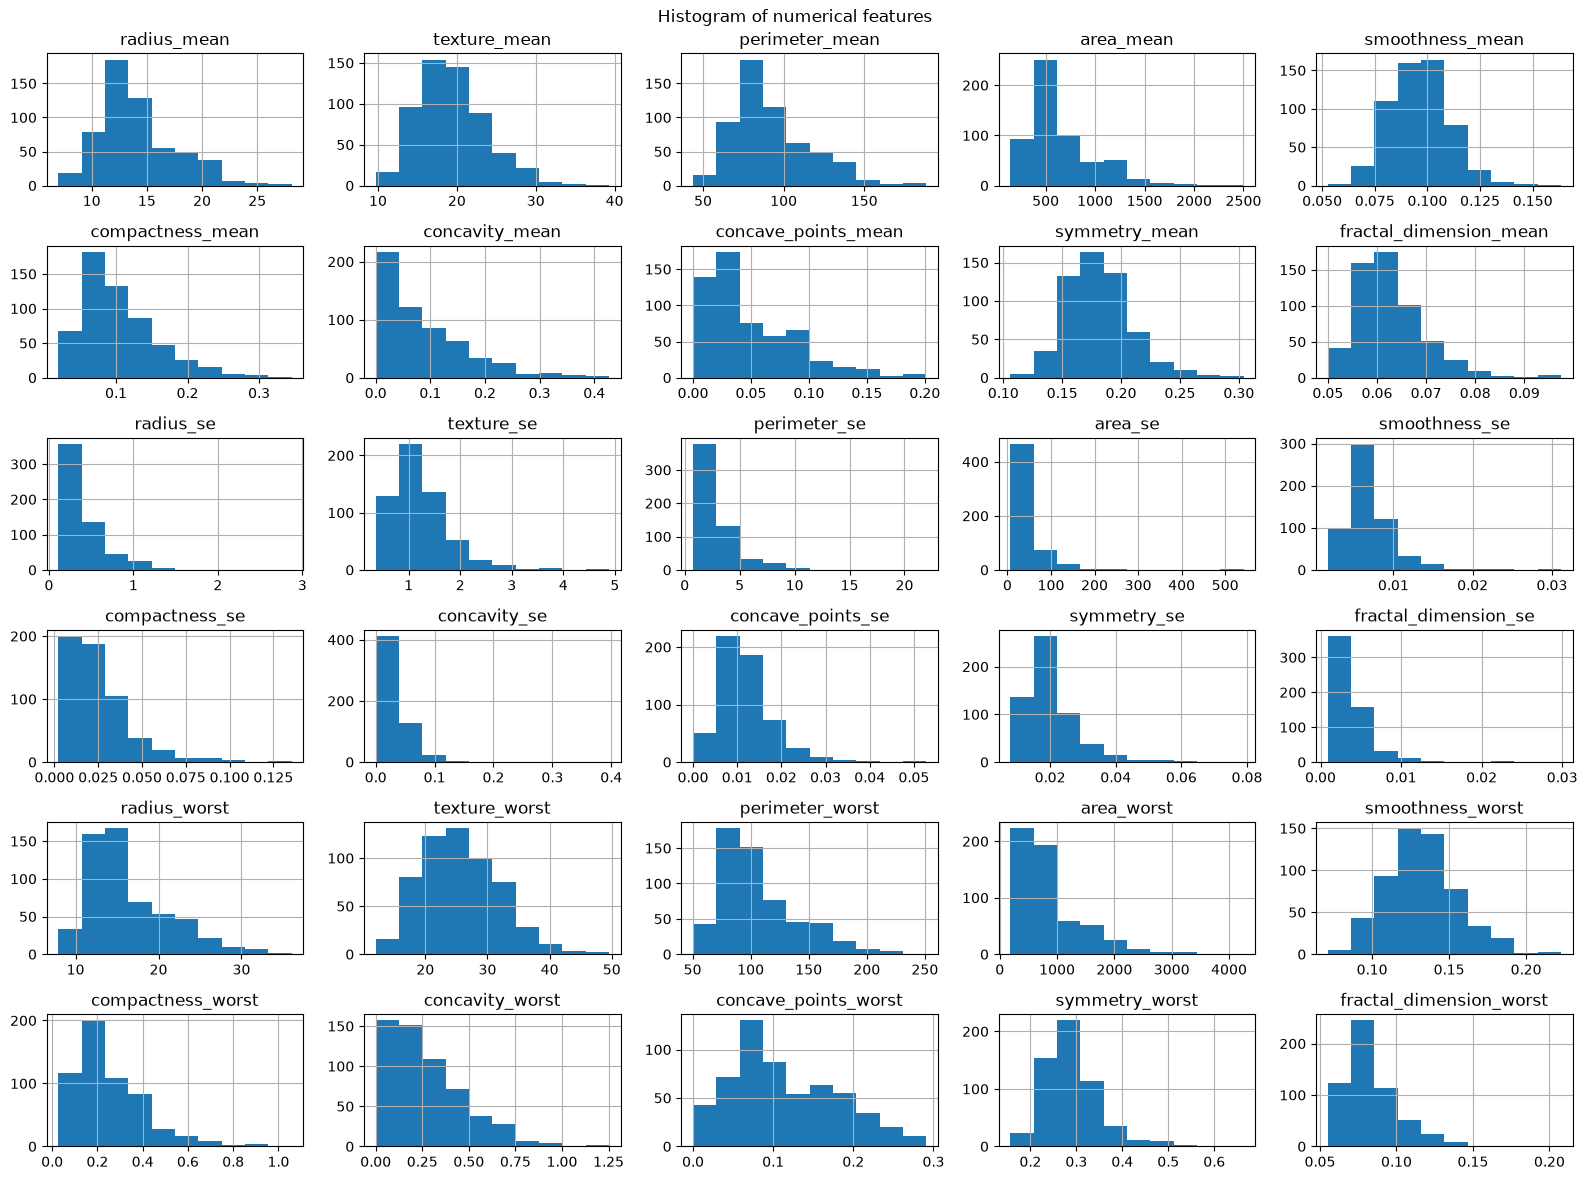

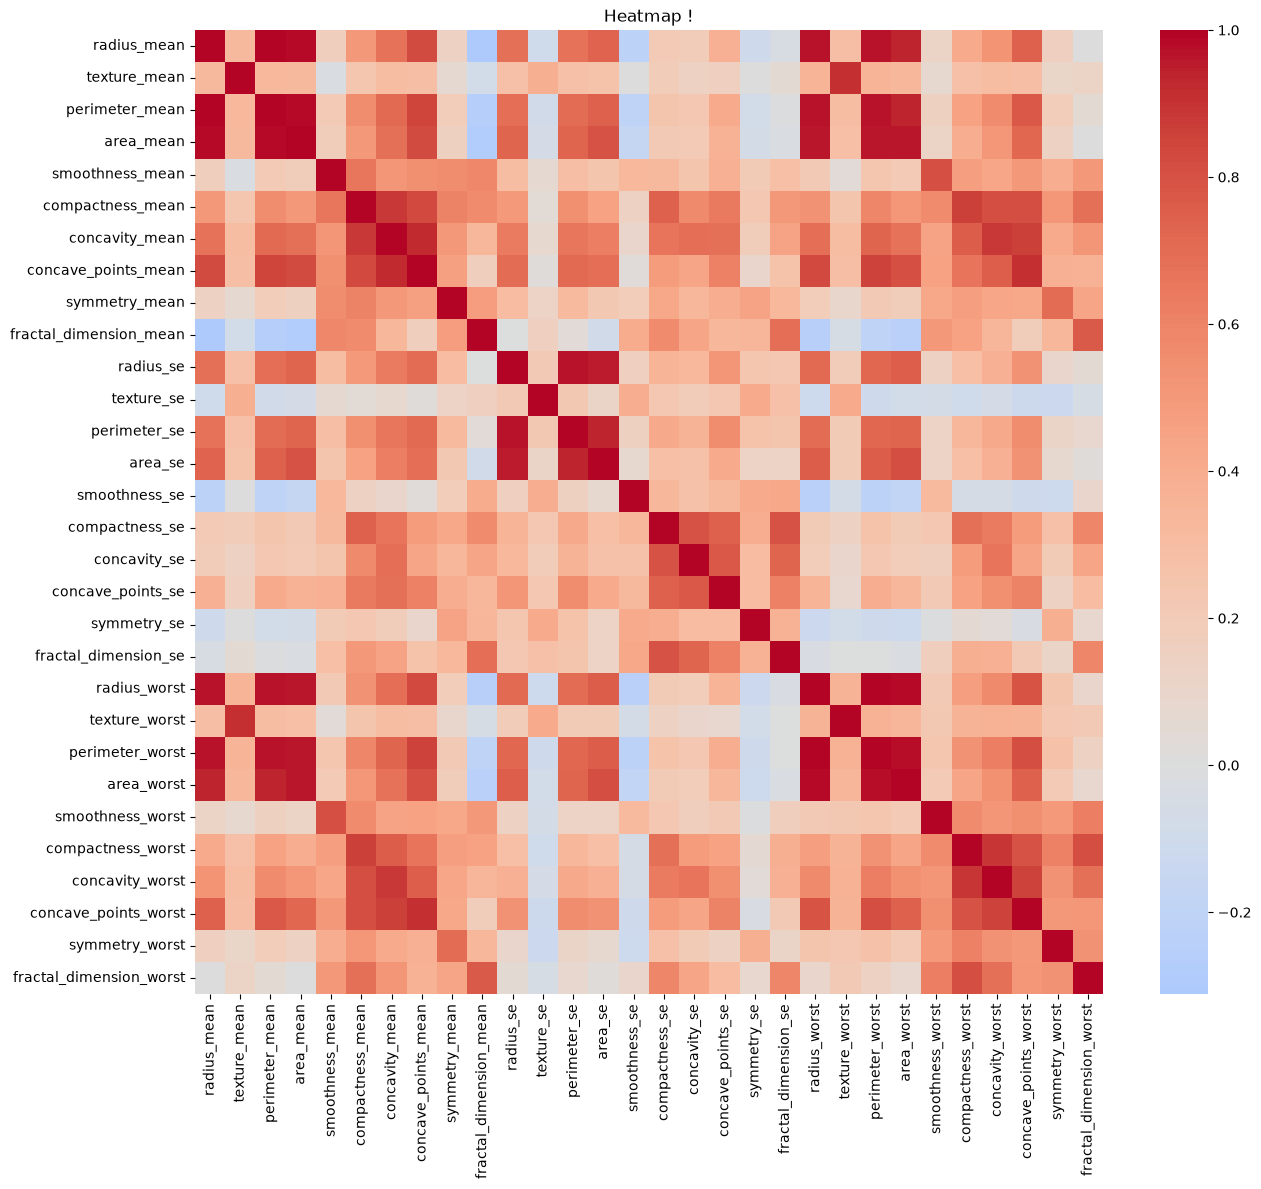


Pairplot skipped (No columns specified).

Class Distribution


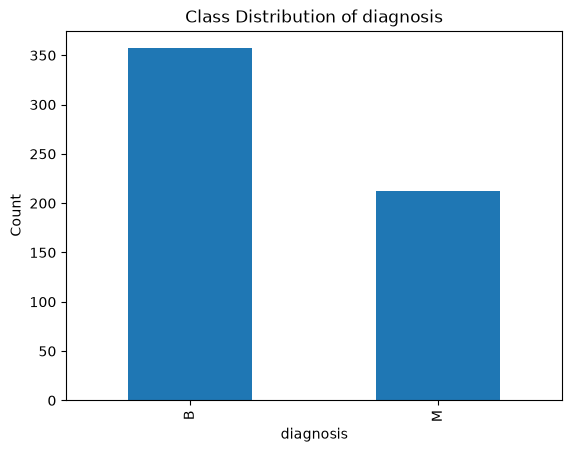

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave_points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave_points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [30]:
features = [
    "radius", "texture", "perimeter", 
    "area", "smoothness",
    "compactness", "concavity", "concave_points", "symmetry", "fractal_dimension"
]
column_names = ["id", "diagnosis"]
for suffix in ["_mean", "_se", "_worst"]:
    column_names.extend([f"{feat}{suffix}" for feat in features])

df = perform_eda("datasets/wdbc.data",column_names=column_names,show_boxplot=False,categorical_columns=["diagnosis"])
display(df.head())

## Train Test Split

In [31]:
from sklearn.model_selection import train_test_split
X = df.drop(['diagnosis'], axis=1)
y = df['diagnosis']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=.2, random_state=42)


In [32]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report

model = DecisionTreeClassifier()
model.fit(X_train, y_train)
y_pred =model.predict(X_test)
# display(model)

print(f"\nTest Accuracy: {accuracy_score(y_test, y_pred):.3f}")
print(f"\nClassification Report:\n {classification_report(y_test, y_pred)}")



Test Accuracy: 0.930

Classification Report:
               precision    recall  f1-score   support

           B       0.96      0.93      0.94        71
           M       0.89      0.93      0.91        43

    accuracy                           0.93       114
   macro avg       0.92      0.93      0.93       114
weighted avg       0.93      0.93      0.93       114



In [33]:
from sklearn.model_selection import GridSearchCV
base_tree = DecisionTreeClassifier(random_state=42)

param_grid = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [3, 5, 10, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

grid_search = GridSearchCV(
    estimator=base_tree,
    param_grid=param_grid,
    cv=5,                 
    scoring='accuracy',   
    n_jobs=-1             
)

grid_search.fit(X_train, y_train)

# Display the best parameter combination and best cross-validation score
print("Best Hyperparameters:", grid_search.best_params_)
print("Best 5-Fold CV Score:", round(grid_search.best_score_, 4))

# 4. Predict and Evaluate using the Best Model on the Test Set
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)

print(f"\nTest Accuracy: {accuracy_score(y_test, y_pred):.3f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Best Hyperparameters: {'criterion': 'entropy', 'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 2}
Best 5-Fold CV Score: 0.9473

Test Accuracy: 0.956

Classification Report:
               precision    recall  f1-score   support

           B       0.95      0.99      0.97        71
           M       0.97      0.91      0.94        43

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



In [34]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
rf_base = RandomForestClassifier(random_state=42)
rf_param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [5, 10, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}
rf_grid_search = GridSearchCV(
    estimator = rf_base,
    param_grid = rf_param_grid,
    cv = 5,
    scoring = 'accuracy',
    n_jobs = -1
)
rf_grid_search.fit(X_train, y_train)

best_rf_model = rf_grid_search.best_estimator_

y_pred_dt = best_model.predict(X_test)
y_pred_rf = best_rf_model.predict(X_test)

print("Best Decision Tree Params:", grid_search.best_params_)
print("Best Random Forest Params:", rf_grid_search.best_params_)

# Calculate metrics for both models (Assumes multi-class/binary classification)
metrics_data = {
    "Model": ["Decision Tree", "Random Forest"],
    "Best CV Score": [grid_search.best_score_, rf_grid_search.best_score_],
    "Test Accuracy": [accuracy_score(y_test, y_pred_dt), accuracy_score(y_test, y_pred_rf)],
    "Precision (Weighted)": [precision_score(y_test, y_pred_dt, average='weighted'), precision_score(y_test, y_pred_rf, average='weighted')],
    "Recall (Weighted)": [recall_score(y_test, y_pred_dt, average='weighted'), recall_score(y_test, y_pred_rf, average='weighted')],
    "F1-Score (Weighted)": [f1_score(y_test, y_pred_dt, average='weighted'), f1_score(y_test, y_pred_rf, average='weighted')]
}

# Display side-by-side comparison table
comparison_df = pd.DataFrame(metrics_data)
display(comparison_df)

Best Decision Tree Params: {'criterion': 'entropy', 'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 2}
Best Random Forest Params: {'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 200}


,Model,Best CV Score,Test Accuracy,Precision (Weighted),Recall (Weighted),F1-Score (Weighted)
0,Decision Tree,0.947253,0.956140,0.956905,0.956140,0.955801
1,Random Forest,0.960440,0.964912,0.965205,0.964912,0.964738
